### Setup and model predictions

Reused the Titanic dataset and a trained classifier for evaluating predictions, not on building new models.


In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# Load Titanic
notebook_path = Path.cwd()
repo_root = notebook_path
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

data_dir = repo_root / "data"
titanic_path = data_dir / "titanic.csv"

df = pd.read_csv(titanic_path)

# Basic cleanup (adjust column names if needed)
df = df.rename(columns={
    "Survived": "survived",
    "Pclass": "pclass",
    "Age": "age",
    "SibSp": "sibsp",
    "Parch": "parch",
    "Fare": "fare",
    "Sex": "sex",
    "Embarked": "embarked"
})

df["class"] = df["pclass"].map({1: "First", 2: "Second", 3: "Third"})

# Simple cleaning
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.dropna(subset=["fare"])

# Features and target
numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked", "class"]

X = df[numeric_features + categorical_features]
y = df["survived"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocessor
numeric_transformer = Pipeline(steps=[
    ("num_imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("cat_imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# Model pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Fit once
clf.fit(X_train, y_train)

# Predictions and probabilities
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # probability of survived=1


### Confusion matrix

A confusion matrix shows counts of:
- True Positives (TP): predicted 1, actual 1
- True Negatives (TN): predicted 0, actual 0
- False Positives (FP): predicted 1, actual 0
- False Negatives (FN): predicted 0, actual 1

From these, we derive precision, recall, F1.


In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)

# If you want it as a DataFrame for nicer display:
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)
print("\nConfusion matrix (labeled):")
display(cm_df)


Confusion matrix:
[[98 12]
 [23 46]]

Confusion matrix (labeled):


,Pred 0,Pred 1
Actual 0,98,12
Actual 1,23,46


### Precision, recall, F1-score

Using the confusion matrix:

- Precision = TP / (TP + FP)
  - "Of all predicted survivors, how many actually survived?"
- Recall = TP / (TP + FN)
  - "Of all actual survivors, how many did we correctly predict?"
- F1 = 2 × (Precision × Recall) / (Precision + Recall)
  - Single number balancing precision and recall.

We use classification_report to get these per class.


In [22]:
# Classification report (precision, recall, F1 per class)
report = classification_report(y_test, y_pred, digits=3)
print("Classification report:\n")
print(report)


Classification report:

              precision    recall  f1-score   support

           0      0.810     0.891     0.848       110
           1      0.793     0.667     0.724        69

    accuracy                          0.804       179
   macro avg      0.802     0.779     0.786       179
weighted avg      0.803     0.804     0.801       179



### ROC curve and AUC

ROC curve plots:
- x-axis: False Positive Rate (FPR)
- y-axis: True Positive Rate (Recall)

Each point corresponds to a different threshold on y_proba.

AUC (Area Under the Curve):
- AUC = 0.5 → random guessing
- AUC = 1.0 → perfect ranking
- Higher is better.

ROC/AUC is good when:
- Classes are somewhat balanced.
- You care about ranking quality more than a specific threshold.


ROC AUC: 0.843


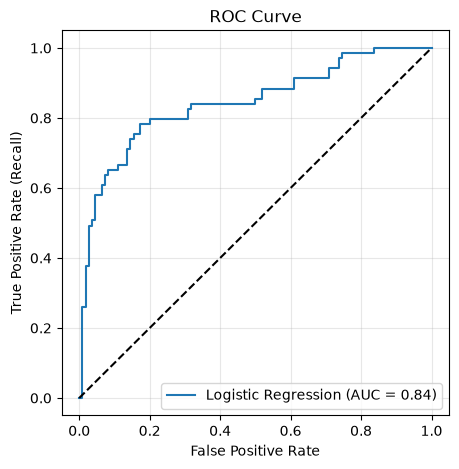

In [23]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

print(f"ROC AUC: {roc_auc:.3f}")

# Plot
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Precision–Recall curve

PR curve plots:
- x-axis: Recall
- y-axis: Precision

Each point corresponds to a different threshold.

Average Precision (AP):
- Single number summarizing the PR curve.
- More informative than ROC AUC when:
  - Classes are imbalanced.
  - You care mostly about the positive class.

Higher AP is better.


Average Precision (AP): 0.786


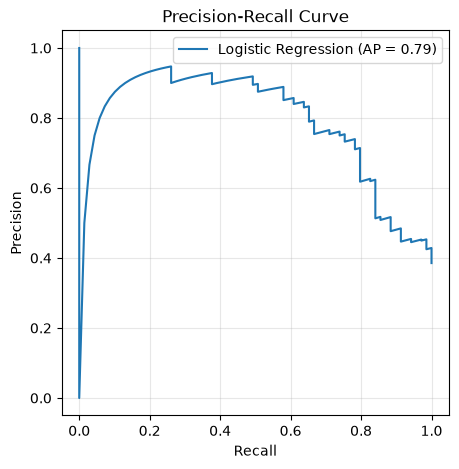

In [24]:
# Precision-Recall curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print(f"Average Precision (AP): {ap:.3f}")

# Plot
plt.figure(figsize=(5, 5))
plt.plot(recall_curve, precision_curve, label=f"Logistic Regression (AP = {ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Threshold tuning

By default, we predict 1 if y_proba >= 0.5.

But 0.5 is arbitrary. We can choose a threshold that:
- Maximizes F1
- Achieves a target recall (e.g. catch 90% of survivors)
- Balances precision and recall differently

We scan thresholds and pick the best according to a chosen goal.


In [25]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Scan thresholds
thresholds_to_try = np.linspace(0.1, 0.9, 17)

results = []

for t in thresholds_to_try:
    y_pred_t = (y_proba >= t).astype(int)
    
    results.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

results_df = pd.DataFrame(results)
display(results_df.round(3))

# Example: threshold that maximizes F1
best_f1_idx = results_df["f1"].idxmax()
best_f1_row = results_df.loc[best_f1_idx]

print("\nThreshold maximizing F1:")
print(best_f1_row)


,threshold,accuracy,precision,recall,f1
0,0.10,0.536,0.450,0.913,0.603
1,0.15,0.631,0.513,0.855,0.641
2,0.20,0.715,0.592,0.841,0.695
3,0.25,0.732,0.618,0.797,0.696
4,0.30,0.771,0.671,0.797,0.728
5,0.35,0.793,0.711,0.783,0.745
6,0.40,0.804,0.750,0.739,0.745
7,0.45,0.799,0.754,0.710,0.731
8,0.50,0.804,0.793,0.667,0.724
9,0.55,0.816,0.833,0.652,0.732



Threshold maximizing F1:
threshold    0.350000
accuracy     0.793296
precision    0.710526
recall       0.782609
f1           0.744828
Name: 5, dtype: float64


In [26]:
# Example: threshold giving recall >= 0.90 (if possible)
target_recall = 0.90
valid = results_df[results_df["recall"] >= target_recall]

if len(valid) > 0:
    best_for_recall = valid.loc[valid["f1"].idxmax()]
    print(f"\nThreshold for recall >= {target_recall}:")
    print(best_for_recall)
else:
    print(f"\nNo threshold achieves recall >= {target_recall} on this test set.")



Threshold for recall >= 0.9:
threshold    0.100000
accuracy     0.536313
precision    0.450000
recall       0.913043
f1           0.602871
Name: 0, dtype: float64


### Optional: Calibration

Calibration checks if predicted probabilities match reality.

- If the model says 70% survival, do about 70% of those passengers actually survive?
- Well-calibrated probabilities are important when you use probabilities for decisions, not just class labels.

We can:
- Plot a calibration curve.
- Optionally refit with calibration (CalibratedClassifierCV).


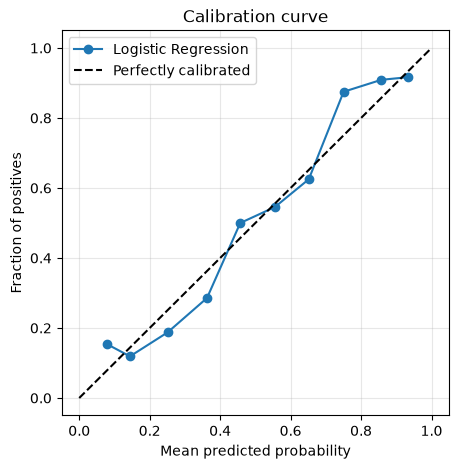

In [27]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Calibration curve for current model
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(prob_pred, prob_true, "o-", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


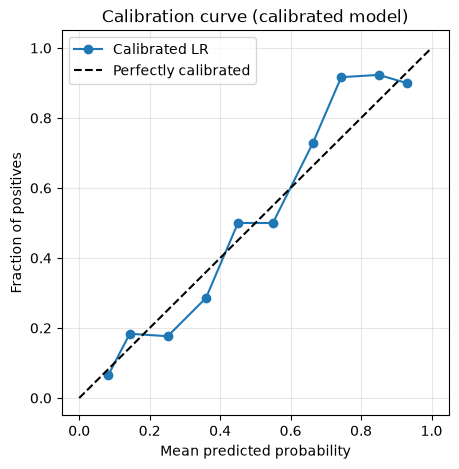

In [28]:
# Calibrated classifier (optional)
calibrated_clf = CalibratedClassifierCV(clf, cv=5, method="sigmoid")
calibrated_clf.fit(X_train, y_train)

y_proba_cal = calibrated_clf.predict_proba(X_test)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.figure(figsize=(5, 5))
plt.plot(prob_pred_cal, prob_true_cal, "o-", label="Calibrated LR")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curve (calibrated model)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
